# Stock Technical Analysis Tool - RSI & MACD Backtesting

## Problem Definition
新手投资者不知道如何判断股票买卖时机。常见的技术指标RSI和MACD难以手动计算和理解。

## Target User
刚接触股票技术分析的投资初学者，希望通过历史数据回测来理解技术指标的有效性。

## Analytical Question
对于Apple股票(AAPL)，基于RSI(<30买入，>70卖出)和MACD(金叉买入，死叉卖出)指标生成的买卖信号，在历史数据上2年内的表现如何？

## Data Source
WRDS (CRSP数据库)
Access Date: April 18, 2026


In [3]:
# 安装WRDS包
!pip install wrds

In [1]:
# 导入所有需要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wrds
from datetime import datetime, timedelta

print("所有库导入成功！")

所有库导入成功！


In [2]:
# 连接WRDS数据库
conn = wrds.Connection()

print("连接成功！")

Enter your WRDS username [wangkeyu]: keyuwang24
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
连接成功！


In [3]:
# 定义参数
ticker = "AAPL"  # 苹果公司
start_date = "2024-04-18"  # 开始日期（2年前）
end_date = "2026-04-18"    # 结束日期

# 从CRSP数据库下载股票数据
query = f"""
    SELECT 
        a.date,
        a.permno,
        a.ret,
        a.vol,
        b.ticker,
        b.comnam
    FROM crsp.dsf as a
    INNER JOIN crsp.stocknames as b
    ON a.permno = b.permno
    AND a.date >= '{start_date}'
    AND a.date <= '{end_date}'
    AND b.ticker = '{ticker}'
    ORDER BY a.date
"""

df = conn.raw_sql(query)

print(f"数据下载成功！")
print(f"数据行数: {df.shape[0]} 行")
print(f"数据列数: {df.shape[1]} 列")
print("\n前5行数据：")
print(df.head())

数据下载成功！
数据行数: 356 行
数据列数: 6 列

前5行数据：
         date  permno       ret         vol ticker              comnam
0  2024-04-18   14593 -0.005714  42706470.0   AAPL           APPLE INC
1  2024-04-18   14593 -0.005714  42706470.0   AAPL  APPLE COMPUTER INC
2  2024-04-19   14593 -0.012213  66845466.0   AAPL  APPLE COMPUTER INC
3  2024-04-19   14593 -0.012213  66845466.0   AAPL           APPLE INC
4  2024-04-22   14593  0.005091  47434012.0   AAPL  APPLE COMPUTER INC


In [4]:
# 关闭WRDS连接
conn.close()
print("WRDS连接已关闭")

WRDS连接已关闭


In [5]:
# 查看数据基本信息
print("=== 数据信息 ===")
df.info()

print("\n=== 检查缺失值 ===")
print(df.isnull().sum())

print("\n=== 数据统计摘要 ===")
print(df.describe())

=== 数据信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    356 non-null    string 
 1   permno  356 non-null    Int64  
 2   ret     356 non-null    Float64
 3   vol     356 non-null    Float64
 4   ticker  356 non-null    string 
 5   comnam  356 non-null    string 
dtypes: Float64(2), Int64(1), string(3)
memory usage: 17.9 KB

=== 检查缺失值 ===
date      0
permno    0
ret       0
vol       0
ticker    0
comnam    0
dtype: int64

=== 数据统计摘要 ===
        permno       ret              vol
count    356.0     356.0            356.0
mean   14593.0  0.002368   54722609.11236
std        0.0   0.01436  33927334.765836
min    14593.0 -0.048167       23146511.0
25%    14593.0 -0.004895       38655670.0
50%    14593.0  0.002655       47082476.5
75%    14593.0  0.010216       59203622.0
max    14593.0  0.072649      315782816.0


In [6]:
# 将收益率转换为价格序列（以100为起点）
df['close'] = (1 + df['ret']).cumprod() * 100

print("价格序列创建成功！")
print(f"价格范围: ${df['close'].min():.2f} - ${df['close'].max():.2f}")
print("\n前10行数据：")
print(df[['date', 'ret', 'close']].head(10))

价格序列创建成功！
价格范围: $96.46 - $239.44

前10行数据：
         date       ret       close
0  2024-04-18 -0.005714     99.4286
1  2024-04-18 -0.005714   98.860465
2  2024-04-19 -0.012213   97.653082
3  2024-04-19 -0.012213   96.460445
4  2024-04-22  0.005091   96.951525
5  2024-04-22  0.005091   97.445105
6  2024-04-23  0.006392   98.067974
7  2024-04-23  0.006392   98.694825
8  2024-04-24  0.012702   99.948447
9  2024-04-24  0.012702  101.217992


In [7]:
def calculate_rsi(data, period=14):
    """计算RSI指标"""
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# 计算14日RSI（基于收益率）
df['rsi'] = calculate_rsi(df['ret'], period=14)

print("RSI计算完成！")
print(f"RSI范围: {df['rsi'].min():.2f} - {df['rsi'].max():.2f}")
print("\n最近10天的RSI值：")
print(df[['date', 'ret', 'rsi']].tail(10))

RSI计算完成！
RSI范围: 24.17 - 75.22

最近10天的RSI值：
           date       ret        rsi
346  2024-12-24  0.011478  54.968967
347  2024-12-24  0.011478  54.968967
348  2024-12-26  0.003176  45.960474
349  2024-12-26  0.003176  45.960474
350  2024-12-27 -0.013242  40.453502
351  2024-12-27 -0.013242  40.453502
352  2024-12-30 -0.013263  54.576355
353  2024-12-30 -0.013263  54.576355
354  2024-12-31 -0.007058  39.483792
355  2024-12-31 -0.007058  39.483792


In [13]:
def calculate_macd(data, fast=12, slow=26, signal=9):
    """计算MACD指标"""
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

# 计算MACD（基于收益率）
df['macd'], df['macd_signal'], df['macd_histogram'] = calculate_macd(df['ret'])

print("MACD计算完成！")
print("\n最近15天的MACD值：")
print(df[['date', 'macd', 'macd_signal', 'macd_histogram']].tail(15))

MACD计算完成！

最近15天的MACD值：
           date      macd  macd_signal  macd_histogram
341  2024-12-19 -0.001447    -0.001057       -0.000390
342  2024-12-20  0.000079    -0.000830        0.000908
343  2024-12-20  0.001273    -0.000409        0.001682
344  2024-12-23  0.000938    -0.000140        0.001078
345  2024-12-23  0.000665     0.000021        0.000643
346  2024-12-24  0.001114     0.000240        0.000874
347  2024-12-24  0.001454     0.000483        0.000971
348  2024-12-26  0.001041     0.000594        0.000446
349  2024-12-26  0.000705     0.000616        0.000089
350  2024-12-27 -0.000875     0.000318       -0.001193
351  2024-12-27 -0.002104    -0.000166       -0.001937
352  2024-12-30 -0.003044    -0.000742       -0.002302
353  2024-12-30 -0.003745    -0.001342       -0.002403
354  2024-12-31 -0.003758    -0.001825       -0.001932
355  2024-12-31 -0.003724    -0.002205       -0.001519


In [14]:
# 生成RSI信号
df['rsi_signal'] = 0
df.loc[df['rsi'] < 30, 'rsi_signal'] = 1   # 买入信号
df.loc[df['rsi'] > 70, 'rsi_signal'] = -1  # 卖出信号

# 生成MACD信号
df['macd_signal_prev'] = df['macd_signal'].shift(1)
df['macd_cross'] = 0
df.loc[(df['macd'] > df['macd_signal']) & (df['macd_signal_prev'] > df['macd_signal_prev']), 'macd_cross'] = 1   # 金叉买入
df.loc[(df['macd'] < df['macd_signal']) & (df['macd_signal_prev'] < df['macd_signal_prev']), 'macd_cross'] = -1  # 死叉卖出

print("信号生成完成！")
print("\n最近20天的信号：")
print(df[['date', 'close', 'rsi', 'rsi_signal', 'macd', 'macd_signal', 'macd_cross']].tail(20))

信号生成完成！

最近20天的信号：
           date       close        rsi  rsi_signal      macd  macd_signal  \
336  2024-12-17  227.095079  57.792429           0  0.000820     0.000048   
337  2024-12-17  229.302444  57.792429           0  0.001050     0.000249   
338  2024-12-18  224.390327  27.082952           1 -0.001265    -0.000054   
339  2024-12-18  219.583437  27.082952           1 -0.003065    -0.000656   
340  2024-12-19  221.123815  51.464861           0 -0.002171    -0.000959   
341  2024-12-19  222.674998  51.464861           0 -0.001447    -0.001057   
342  2024-12-20  226.864851  61.891350           0  0.000079    -0.000830   
343  2024-12-20   231.13354  61.891350           0  0.001273    -0.000409   
344  2024-12-23  231.841965  48.625532           0  0.000938    -0.000140   
345  2024-12-23   232.55256  48.625532           0  0.000665     0.000021   
346  2024-12-24  235.221798  54.968967           0  0.001114     0.000240   
347  2024-12-24  237.921674  54.968967           0  0.001

In [16]:
# 计算未来收益率
df['future_return_5d'] = df['ret'].shift(-5)  # 5天后收益率
df['future_return_10d'] = df['ret'].shift(-10) # 10天后收益率

# RSI买入信号表现
rsi_buy = df[df['rsi_signal'] == 1].copy()
print("=" * 50)
print("RSI买入信号表现")
print("=" * 50)
print(f"RSI买入信号次数: {len(rsi_buy)}")
if len(rsi_buy) > 0:
    print(f"平均5天收益率: {rsi_buy['future_return_5d'].mean():.2%}")
    print(f"平均10天收益率: {rsi_buy['future_return_10d'].mean():.2%}")
    print(f"10天胜率: {(rsi_buy['future_return_10d'] > 0).mean():.1%}")

# MACD买入信号表现
macd_buy = df[df['macd_cross'] == 1].copy()
print("\n" + "=" * 50)
print("MACD金叉买入信号表现")
print("=" * 50)
print(f"MACD买入信号次数: {len(macd_buy)}")
if len(macd_buy) > 0:
    print(f"平均5天收益率: {macd_buy['future_return_5d'].mean():.2%}")
    print(f"平均10天收益率: {macd_buy['future_return_10d'].mean():.2%}")
    print(f"10天胜率: {(macd_buy['future_return_10d'] > 0).mean():.1%}")

RSI买入信号表现
RSI买入信号次数: 18
平均5天收益率: 0.88%
平均10天收益率: -0.18%
10天胜率: 55.6%

MACD金叉买入信号表现
MACD买入信号次数: 0


In [18]:
import os
os.makedirs('figures', exist_ok=True)
print("figures文件夹已创建！")

figures文件夹已创建！


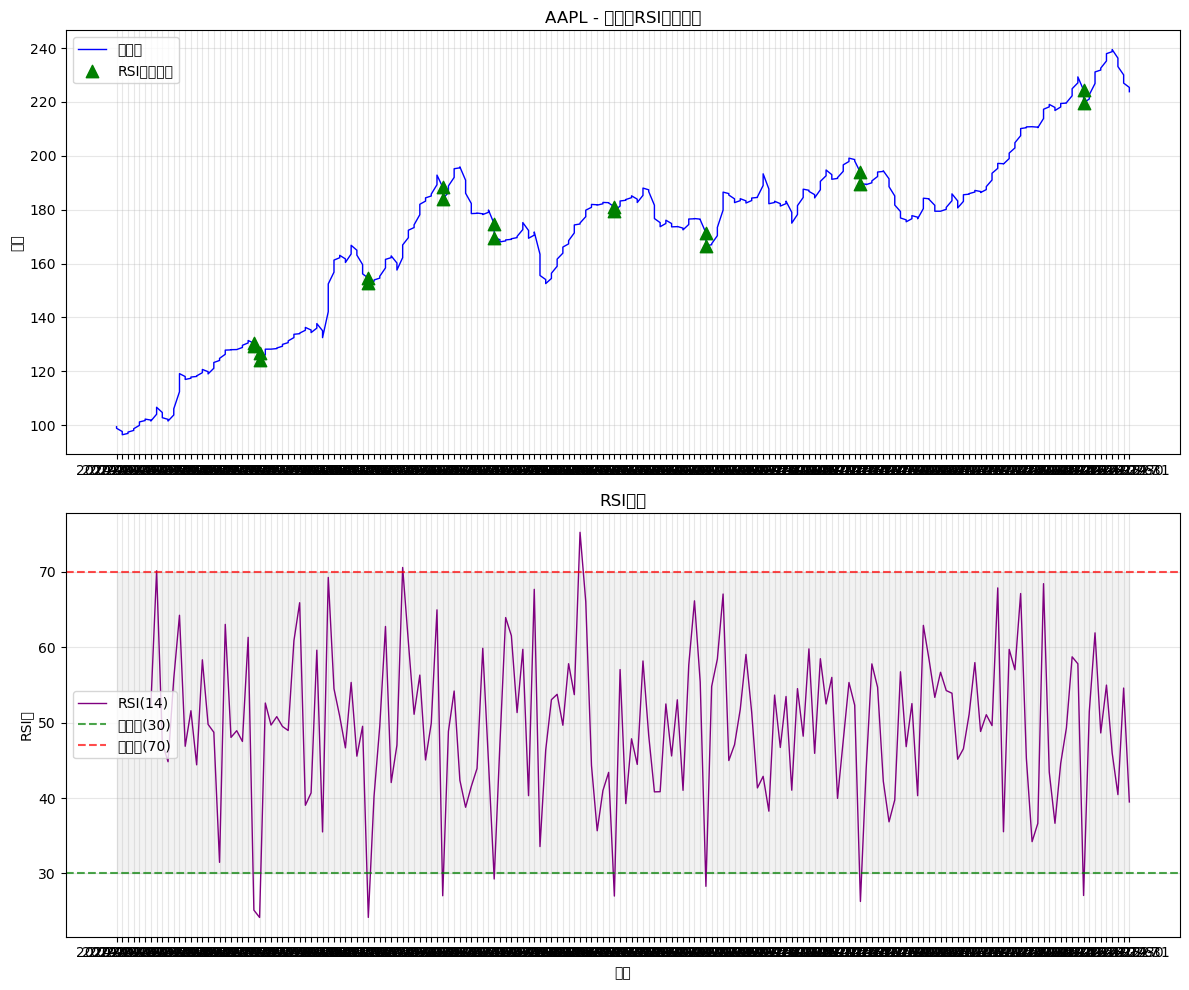

图表已保存到 figures/rsi_analysis.png


In [21]:
# 定义股票代码
ticker = "AAPL"

# 设置图表风格
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 图1：价格和RSI信号
ax1.plot(df['date'], df['close'], color='blue', linewidth=1, label='收盘价')
ax1.scatter(df[df['rsi_signal'] == 1]['date'], 
            df[df['rsi_signal'] == 1]['close'], 
            color='green', marker='^', s=80, label='RSI买入信号', zorder=5)
ax1.set_title(f'{ticker} - 价格与RSI买入信号')
ax1.set_ylabel('价格')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：RSI指标
ax2.plot(df['date'], df['rsi'], color='purple', linewidth=1, label='RSI(14)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, label='超卖线(30)')
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, label='超买线(70)')
ax2.fill_between(df['date'], 30, 70, alpha=0.1, color='gray')
ax2.set_title('RSI指标')
ax2.set_ylabel('RSI值')
ax2.set_xlabel('日期')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/rsi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("图表已保存到 figures/rsi_analysis.png")


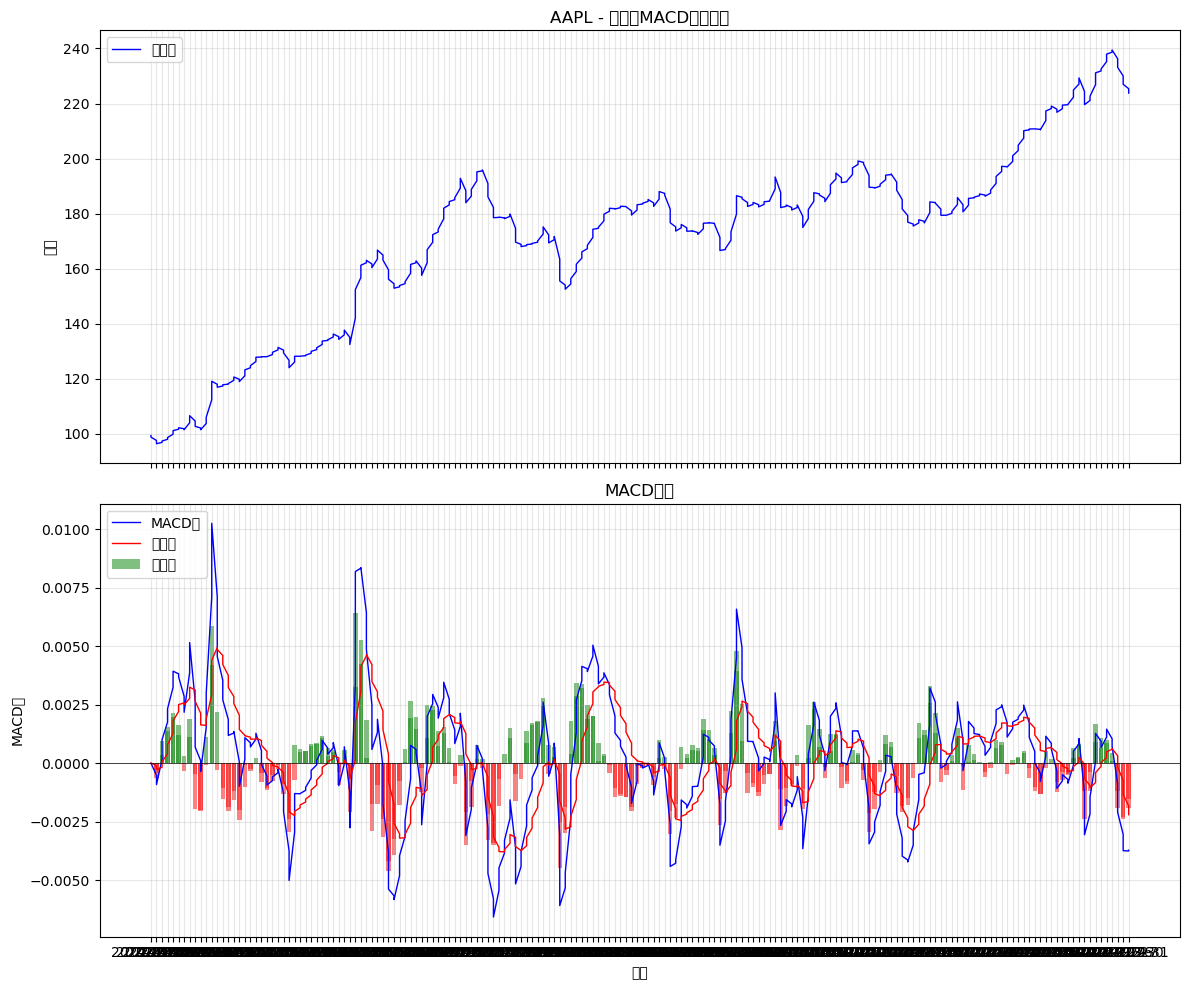

MACD图表已保存到 figures/macd_analysis.png


In [22]:
# MACD图表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 图1：价格和MACD金叉信号
ax1.plot(df['date'], df['close'], color='blue', linewidth=1, label='收盘价')

# 标记MACD金叉（如果有的话）
macd_buy = df[df['macd_cross'] == 1]
if len(macd_buy) > 0:
    ax1.scatter(macd_buy['date'], macd_buy['close'], 
                color='green', marker='^', s=100, label='MACD金叉买入', zorder=5)

ax1.set_title(f'{ticker} - 价格与MACD金叉信号')
ax1.set_ylabel('价格')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 图2：MACD指标
ax2.plot(df['date'], df['macd'], color='blue', linewidth=1, label='MACD线')
ax2.plot(df['date'], df['macd_signal'], color='red', linewidth=1, label='信号线')
# MACD柱状图
colors = ['green' if val >= 0 else 'red' for val in df['macd_histogram']]
ax2.bar(df['date'], df['macd_histogram'], color=colors, alpha=0.5, width=0.8, label='柱状图')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('MACD指标')
ax2.set_ylabel('MACD值')
ax2.set_xlabel('日期')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/macd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("MACD图表已保存到 figures/macd_analysis.png")

In [23]:
# 生成 requirements.txt
requirements = """
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
wrds>=3.0.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements.strip())

print("requirements.txt 已创建！")
print("\n文件内容：")
print(requirements)

requirements.txt 已创建！

文件内容：

pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
wrds>=3.0.0

